# MATH 428 / CISC 411 Project 2: Soliton Waves and Shallow Water Equations

**Name:** Oluwatobi Banjo  
**Course:** MATH 428 / CISC 411  
**Project:** Project 2  
**Topic:** Soliton Waves and Shallow Water Equations

This notebook contains the Julia source code, figures, and discussion for Project 2. The notebook is organized into the required parts:

1. Single-soliton KdV simulation
2. Two-soliton interaction
3. Shallow water equations

The code is written so that all numerical results, plots, and the animation can be reproduced by restarting the Julia kernel and selecting **Run All**.

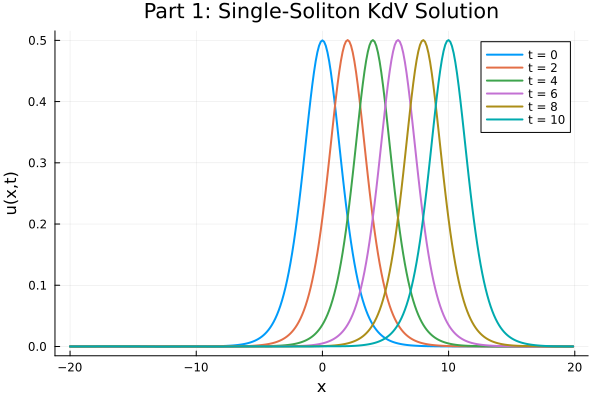

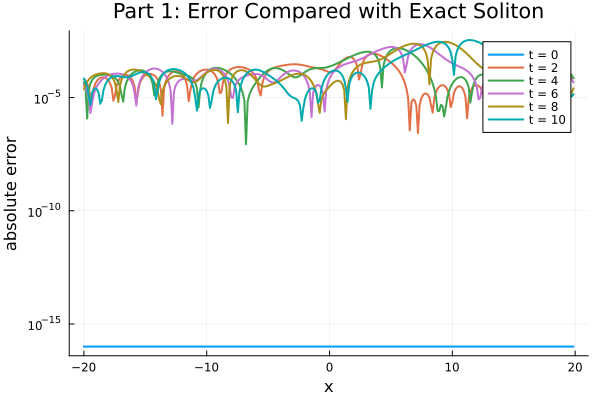

"/Users/tobibanjo/Downloads/shallow-water-soliton-project/part1_single_soliton_error.png"

In [1]:
using LinearAlgebra
using SparseArrays
using OrdinaryDiffEq
using OrdinaryDiffEqRosenbrock
using Plots
using OrdinaryDiffEqTsit5
# ------------------------------------------------------------
# Part 1: Single-Soliton KdV Simulation
# ------------------------------------------------------------

# Define sech since Julia does not have it built in
sech(z) = 1 / cosh(z)

# One-soliton solution:
# s(x,t;c) = c/2 * sech^2( sqrt(c)/2 * (x - c*t) )
function soliton(x, t, c)
    return (c / 2) * sech((sqrt(c) / 2) * (x - c * t))^2
end

function soliton_profile(x, t, c)
    return soliton.(x, t, c)
end

# ------------------------------------------------------------
# Periodic first derivative matrix
# ------------------------------------------------------------

function periodic_Dx(m, a, b)
    L = b - a
    dx = L / m

    Dx = spzeros(m, m)

    for i in 1:m
        ip = i == m ? 1 : i + 1
        im = i == 1 ? m : i - 1

        Dx[i, ip] = 1 / (2dx)
        Dx[i, im] = -1 / (2dx)
    end

    return Dx
end

# ------------------------------------------------------------
# Periodic third derivative matrix
# Uses the centered finite difference formula:
#
# f'''(x_i) ≈ (f_{i+2} - 2f_{i+1} + 2f_{i-1} - f_{i-2}) / (2 dx^3)
# ------------------------------------------------------------

function periodic_Dxxx(m, a, b)
    L = b - a
    dx = L / m

    Dxxx = spzeros(m, m)

    for i in 1:m
        ip1 = i == m ? 1 : i + 1
        ip2 = i >= m - 1 ? i + 2 - m : i + 2

        im1 = i == 1 ? m : i - 1
        im2 = i <= 2 ? i - 2 + m : i - 2

        Dxxx[i, ip2] = 1 / (2dx^3)
        Dxxx[i, ip1] = -2 / (2dx^3)
        Dxxx[i, im1] = 2 / (2dx^3)
        Dxxx[i, im2] = -1 / (2dx^3)
    end

    return Dxxx
end

# ------------------------------------------------------------
# KdV right-hand side
#
# u_t + 6u u_x + u_xxx = 0
#
# Therefore:
# u_t = -6u u_x - u_xxx
# ------------------------------------------------------------

function kdv_rhs!(du, u, p, t)
    Dx = p.Dx
    Dxxx = p.Dxxx

    ux = Dx * u
    uxxx = Dxxx * u

    du .= -6.0 .* u .* ux .- uxxx
end

# ------------------------------------------------------------
# Set up spatial grid
# ------------------------------------------------------------

a = -20.0
b = 20.0
m = 300

dx = (b - a) / m

# Periodic grid, so we do not include the repeated endpoint b
x = a .+ dx .* collect(0:m-1)

# Build derivative matrices
Dx = periodic_Dx(m, a, b)
Dxxx = periodic_Dxxx(m, a, b)

# ------------------------------------------------------------
# Initial condition
# u(x,0) = s(x,0;1)
# ------------------------------------------------------------

c = 1.0
u0 = soliton_profile(x, 0.0, c)

# Time interval
tspan = (0.0, 10.0)

# Required output times
save_times = 0.0:2.0:10.0

# Parameters passed into the RHS function
p = (Dx = Dx, Dxxx = Dxxx)

# Define the ODE problem
prob = ODEProblem(kdv_rhs!, u0, tspan, p)

# ------------------------------------------------------------
# Solve using a stiff solver
# ------------------------------------------------------------

sol = solve(
    prob,
    Rodas4P(),
    saveat = save_times,
    reltol = 1e-8,
    abstol = 1e-10
)

# ------------------------------------------------------------
# Figure 1: Numerical solution at t = 0,2,4,6,8,10
# ------------------------------------------------------------

plt1 = plot(
    xlabel = "x",
    ylabel = "u(x,t)",
    title = "Part 1: Single-Soliton KdV Solution",
    legend = :topright
)

for (j, t) in enumerate(sol.t)
    plot!(
        plt1,
        x,
        sol.u[j],
        linewidth = 2,
        label = "t = $(Int(round(t)))"
    )
end

display(plt1)

savefig(plt1, "part1_single_soliton_solution.png")

# ------------------------------------------------------------
# Figure 2: Absolute error compared with exact soliton solution
# Log scale on the vertical axis
# ------------------------------------------------------------

plt2 = plot(
    xlabel = "x",
    ylabel = "absolute error",
    title = "Part 1: Error Compared with Exact Soliton",
    yscale = :log10,
    legend = :topright
)

for (j, t) in enumerate(sol.t)
    exact = soliton_profile(x, t, c)
    error = abs.(sol.u[j] .- exact)

    # Prevent log(0) from causing plotting issues
    error = max.(error, 1e-16)

    plot!(
        plt2,
        x,
        error,
        linewidth = 2,
        label = "t = $(Int(round(t)))"
    )
end

display(plt2)

savefig(plt2, "part1_single_soliton_error.png")

## Part 1 Discussion

The numerical solution shows the single soliton traveling to the right while mostly keeping its shape. This agrees with the expected behavior of the exact one-soliton solution. The error plot compares the numerical solution with the exact solution at \(t=0,2,4,6,8,10\). The error stays small overall, with small differences caused by the spatial finite-difference approximation and the time solver.

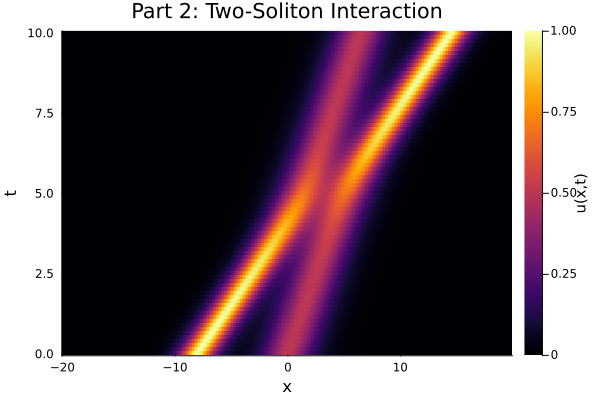

"/Users/tobibanjo/Downloads/shallow-water-soliton-project/part2_two_soliton_heatmap.png"

In [2]:
# ------------------------------------------------------------
# Part 2: Two-Soliton Interaction
# ------------------------------------------------------------

# We reuse the same KdV RHS, soliton function, and derivative matrices from Part 1.

# Spatial domain
a = -20.0
b = 20.0
m = 300

dx = (b - a) / m
x = a .+ dx .* collect(0:m-1)

# Build derivative matrices
Dx = periodic_Dx(m, a, b)
Dxxx = periodic_Dxxx(m, a, b)

# ------------------------------------------------------------
# Initial condition:
#
# u(x,0) = s(x,0;1) + s(x+8,0;2)
#
# The second soliton is centered near x = -8 and has speed c = 2.
# ------------------------------------------------------------

u0_part2 = soliton_profile(x, 0.0, 1.0) .+ soliton_profile(x .+ 8.0, 0.0, 2.0)

# Time interval
tspan = (0.0, 10.0)

# 81 equally spaced times in [0,10]
t_values = range(0.0, 10.0, length = 81)

# Pack parameters
p = (Dx = Dx, Dxxx = Dxxx)

# Define the ODE problem
prob2 = ODEProblem(kdv_rhs!, u0_part2, tspan, p)

# Solve using a stiff solver
sol2 = solve(
    prob2,
    Rodas4P(),
    saveat = t_values,
    reltol = 1e-8,
    abstol = 1e-10
);
U = reduce(hcat, sol2.u)'

plt3 = heatmap(
    x,
    sol2.t,
    U,
    xlabel = "x",
    ylabel = "t",
    title = "Part 2: Two-Soliton Interaction",
    colorbar_title = "u(x,t)"
)

display(plt3)

savefig(plt3, "part2_two_soliton_heatmap.png")

## Part 2 Discussion

The heatmap shows the two-soliton interaction over space and time. The faster soliton starts on the left because \(s(x+8,0;2)\) is centered near \(x=-8\). Since it has the larger speed, it catches and passes the slower soliton. After the interaction, both waves continue moving while mostly keeping their shapes.

In [3]:
# ------------------------------------------------------------
# Part 3: Shallow Water Equations
# ------------------------------------------------------------

# We reuse periodic_Dx from Part 1.

# Spatial domain
a3 = -8.0
b3 = 8.0
m3 = 400

dx3 = (b3 - a3) / m3
x3 = a3 .+ dx3 .* collect(0:m3-1)

# Periodic first derivative matrix
Dx3 = periodic_Dx(m3, a3, b3)

# Friction parameter
epsilon = 0.7

# Depth function:
# delta(x) = -2 + 1.75 exp(-2(x - 4)^2)
function delta_fun(x)
    return -2.0 + 1.75 * exp(-2.0 * (x - 4.0)^2)
end

delta_vals = delta_fun.(x3)

# Initial conditions:
# h(x,0) = exp(-x^2/2)
# u(x,0) = 0

h0 = exp.(-(x3 .^ 2) ./ 2.0)
u0_swe = zeros(m3)

# The solver wants one long vector v = [h; u]
v0 = [h0; u0_swe]

800-element Vector{Float64}:
 1.2664165549094176e-14
 1.742622742998039e-14
 2.394061514095669e-14
 3.28376720656351e-14
 4.4969136320233276e-14
 6.148396412704778e-14
 8.392943572505959e-14
 1.1438573703559516e-13
 1.5564478550463911e-13
 2.1144742687895444e-13
 ⋮
 0.0
 0.0
 0.0
 0.0
 0.0
 0.0
 0.0
 0.0
 0.0

In [4]:
# ------------------------------------------------------------
# Shallow Water Equations RHS
#
# h_t + ((h - delta)u)_x = 0
# u_t + u*u_x = -h_x - epsilon*u
#
# The vector v is packed as:
# v = [h; u]
# ------------------------------------------------------------

function swe_rhs!(dv, v, p, t)
    Dx = p.Dx
    delta_vals = p.delta_vals
    epsilon = p.epsilon
    m = p.m

    # Unpack v = [h; u]
    h = @view v[1:m]
    u = @view v[(m+1):(2*m)]

    # Unpack dv = [dhdt; dudt]
    dhdt = @view dv[1:m]
    dudt = @view dv[(m+1):(2*m)]

    # Compute needed derivatives
    flux = (h .- delta_vals) .* u
    hx = Dx * h
    ux = Dx * u

    # Shallow water equations
    dhdt .= -(Dx * flux)
    dudt .= -u .* ux .- hx .- epsilon .* u
end

swe_rhs! (generic function with 1 method)

In [5]:
# ------------------------------------------------------------
# Solve Part 3
# ------------------------------------------------------------

# Time interval
tspan3 = (0.0, 10.0)

# 100 equally spaced output times in [0,10]
t_values3 = range(0.0, 10.0, length = 100)

# Pack parameters
p3 = (
    Dx = Dx3,
    delta_vals = delta_vals,
    epsilon = epsilon,
    m = m3
)

# Define ODE problem
prob3 = ODEProblem(swe_rhs!, v0, tspan3, p3)

# Solve using nonstiff adaptive solver
sol3 = solve(
    prob3,
    Tsit5(),
    saveat = t_values3,
    reltol = 1e-7,
    abstol = 1e-9
);

┌ Info: Saved animation to /Users/tobibanjo/Downloads/shallow-water-soliton-project/part3_shallow_water_animation.gif
└ @ Plots /Users/tobibanjo/.julia/packages/Plots/AE0LB/src/animation.jl:156


Plots.AnimatedGif("/Users/tobibanjo/Downloads/shallow-water-soliton-project/part3_shallow_water_animation.gif")
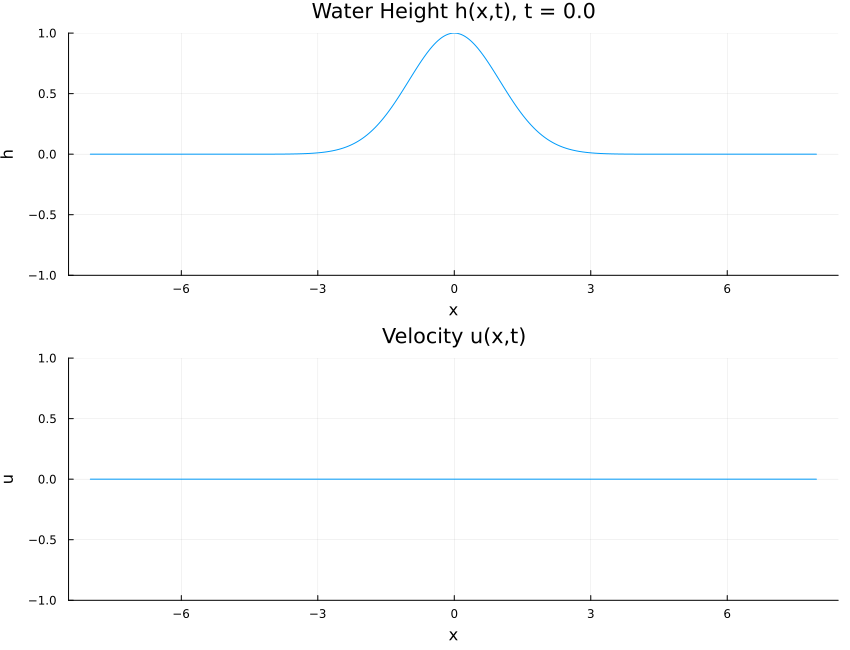

In [6]:
# ------------------------------------------------------------
# Required Part 3 animated GIF
# Top subplot: h versus x
# Bottom subplot: u versus x
# ------------------------------------------------------------

anim = @animate for k in 1:length(sol3.t)

    current_t = sol3.t[k]
    current_v = sol3.u[k]

    h_current = current_v[1:m3]
    u_current = current_v[(m3+1):(2*m3)]

    p1 = plot(
        x3,
        h_current,
        xlabel = "x",
        ylabel = "h",
        title = "Water Height h(x,t), t = $(round(current_t, digits=2))",
        ylims = (-1, 1),
        legend = false
    )

    p2 = plot(
        x3,
        u_current,
        xlabel = "x",
        ylabel = "u",
        title = "Velocity u(x,t)",
        ylims = (-1, 1),
        legend = false
    )

    plot(
        p1,
        p2,
        layout = (2, 1),
        size = (850, 650)
    )
end

gif(anim, "part3_shallow_water_animation.gif", fps = 15)

## Part 3 Discussion

For Part 3, I solved the shallow water equations on the periodic domain from -8 to 8 using 400 grid points. The initial height was a Gaussian wave, and the initial velocity was zero. The depth function creates a bump near x = 4, and the friction value epsilon = 0.7 causes the waves to slow down over time.

The variables h and u were packed into one vector, v = [h; u], for the ODE solver. Inside the right-hand side function, I unpacked the vector and used the periodic derivative matrix to compute the spatial derivatives.

The animation shows the wave spreading outward, interacting with the bump, and separating into smaller waves. As time increases, friction causes the wave motion to settle.

## Conclusion

In this project, I used the method of lines to simulate nonlinear wave equations. The KdV simulations showed soliton waves traveling while mostly keeping their shape. In the two-soliton case, the faster soliton overtook the slower one and both continued moving after the interaction.

For the shallow water equations, the wave interacted with the bottom bump and gradually settled because of friction. Overall, the project showed how finite-difference methods and ODE solvers can be used to study wave behavior numerically.